**Segmentacija fotografija uz pomoć mašinskog učenja**

Segmentacija fotografije je proces podele digitalne fotografije na više segmenata (skupova piksela). Cilj segmentacije je pojednostavljivanje i/ili promena prikaza fotografije u nešto što je značajnije i lakše za analizu. Segmentacija se obično koristi za lociranje objekata i granica (linija, ivica itd.) na fotografijama.

Da budemo precizniji, segmentacija fotografije je postupak dodeljivanja oznake svakom pikselu na fotografiji tako da pikseli sa istom oznakom dele određene karakteristike, kao što su boja, tekstura ili prostorna povezanost.

Postoji više različitih algoritama koji se koriste za realizaciju ovog procesa — kao što su thresholding, region growing, clustering metode, watershed ili metode zasnovane na mašinskom učenju. Izbor odgovarajućeg pristupa zavisi od same prirode slike: neki algoritmi daju bolje rezultate na slikama sa jasno odvojenim objektima, dok su drugi pogodniji za složenije i šumovitije scene.

U savremenim sistemima, segmentacija se često unapređuje mašinskim učenjem, naročito kada je potrebno postići veću fleksibilnost i preciznost. Ovakvi modeli mogu se trenirati da prepoznaju obrasce i samostalno poboljšaju tačnost segmentacije.

U našem slučaju, za segmentaciju medicinskih fotografija koristićemo U-net model, koji koristi algoritam učenja zasnovan na konvolucionim neuronskim mrežama (CNN) kako bi naučio da segmentira slike. Sama segmentacija se ne zasniva na standardnim algoritmima kao što su watershed, thresholding, već na treningu modela na skupu označenih slika koristeći optimizacione algoritme poput Adam.

**Prednosti i ograničenja segmentacije**

Segmentacija slike predstavlja ključni korak u obradi i analizi digitalnih fotografija, posebno u kontekstu izdvajanja objekata od pozadine i pripreme podataka za dalje faze analize, kao što su klasifikacija ili prepoznavanje. Ipak, kao i većina algoritamskih tehnika, i segmentacija ima svoje prednosti i ograničenja.

Glavna prednost segmentacije je ta što pojednostavljuje analizu slike. Znači, umesto da analiziramo milione pixela, fokusiramo se samo na relevantne regione fotografije.

Ipak, jedna od glavnih mana je ta što sama segmentacija zavisi od kvaliteta slike. Konkretno, ukoliko je na slici prisutan šum, slab kontrast, refleksije i senke, to može značajno pogoršati rezultat segmentacije, jer neće dati relevantne rezultate.

**Realizacija segmentacije**

U narednoj sekciji ćemo detaljno opisati kreiranje modela koji vrši segmentaciju tumora.

Pre svega, importovaćemo neophodne biblioteke za preuzimanje dataseta i unzipa istog;

In [ ]:
# 1. Instalacija gdown i preuzimanje dataseta
!pip install gdown
import gdown

url = 'https://drive.google.com/uc?export=download&id=1gMX4DO9PORppEVnZwp2OH3bRMyB1MoAO'
output = 'dataset.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1gMX4DO9PORppEVnZwp2OH3bRMyB1MoAO
From (redirected): https://drive.google.com/uc?export=download&id=1gMX4DO9PORppEVnZwp2OH3bRMyB1MoAO&confirm=t&uuid=40276781-f452-4870-9940-c13758ea448c
To: /content/dataset.zip
100%|██████████| 204M/204M [00:03<00:00, 66.7MB/s]


'dataset.zip'

In [ ]:
# 2. Otpakivanje dataseta
import zipfile
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

Osim standardnih biblioteka za rad sa fajlovima, uvozimo biblioteku
**train_test_split** koju koristimo da podatke podelimo na trening i test skupove

In [ ]:
# 3. Ucitavanje biblioteka
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# Pravimo prazne liste za čuvanje putanja do slika i maski
image_paths = []
mask_paths = []

# Definišemo kategorije klasa u datasetu
base_path = 'dataset/Dataset_BUSI_with_GT'
classes = ['benign', 'malignant', 'normal']

# Za svaku klasu prolazimo kroz folder sa slikama
for cls in classes:
    folder_path = os.path.join(base_path, cls)  # Putanja do foldera klase
    files = sorted(os.listdir(folder_path))     # Sortiramo fajlove u folderu

    for file in files:
        if '_mask' not in file:                 # Preskačemo fajlove koji su maske
            image_path = os.path.join(folder_path, file)  # Putanja do slike
            mask_path = os.path.join(folder_path, file.replace(')', ')_mask'))  # Putanja do maske
            if os.path.exists(mask_path):       # Proveravamo da li maska postoji
                image_paths.append(image_path)  # Dodajemo putanju slike u listu
                mask_paths.append(mask_path)    # Dodajemo putanju maske u listu

In [ ]:
# Definišemo željenu veličinu slika
IMG_SIZE = 128

# Pravimo prazne liste za slike i maske
X = []
Y = []

# Za svaku sliku i pripadajuću masku
for img_path, mask_path in zip(image_paths, mask_paths):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Učitavamo sliku i masku u sivim tonovima
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) 

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))   # Menjamo veličinu slike i maske na 128x128
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) 

    img = img / 255.0   # Normalizujemo vrednosti piksela slike i maske u opsegu [0,1]
    mask = mask / 255.0

    X.append(img)       # Dodajemo pripremljenu sliku i masku u listu X i Y
    Y.append(mask)

# Pretvaramo liste u numpy nizove i dodajemo dimenziju za kanal (1 kanal - grayscale)
X = np.expand_dims(np.array(X), axis=-1)
Y = np.expand_dims(np.array(Y), axis=-1)

In [ ]:
# Delimo podatke na trening i test skupove (80% trening, 20% test)
# random_state=42 je fiksni seed da bismo uvek dobili isti raspored
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
import tensorflow as tf  # Uvoz TensorFlow biblioteke

def conv_block(input_tensor, num_filters):
    # 2 konvoluciona sloja sa ReLU aktivacijom, iste dimenzije (padding="same")
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same", activation="relu")(input_tensor)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding="same", activation="relu")(x)
    return x

def encoder_block(input_tensor, num_filters):
    # Konvolucioni blok + max pooling za smanjenje dimenzija (downsampling)
    x = conv_block(input_tensor, num_filters)
    p = tf.keras.layers.MaxPooling2D((2, 2))(x)
    return x, p  # vraća output i pooling za dalje korišćenje

def decoder_block(input_tensor, skip_tensor, num_filters):
    # Transponovana konvolucija za povećanje dimenzija (upsampling)
    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input_tensor)
    # Spajanje sa odgovarajućim encoder slojem (skip connection)
    x = tf.keras.layers.Concatenate()([x, skip_tensor])
    x = conv_block(x, num_filters)
    return x

def build_unet(input_shape):
    inputs = tf.keras.Input(shape=input_shape)  # Definiše ulaz modela sa zadatim oblikom

    s1, p1 = encoder_block(inputs, 64)   # Encoder nivo 1 (64 filtera)
    s2, p2 = encoder_block(p1, 128)       # Encoder nivo 2 (128 filtera)...
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)              # Bottleneck sloj (1024 filtera)

    d1 = decoder_block(b1, s4, 512)       # Decoder nivo 1, spaja sa s4
    d2 = decoder_block(d1, s3, 256)       # Decoder nivo 2, spaja sa s3...
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation="sigmoid")(d4)  # Izlazni sloj za binarnu segmentaciju

    model = tf.keras.Model(inputs, outputs)  # Kreira model sa definisanim ulazom i izlazom
    return model

model = build_unet((IMG_SIZE, IMG_SIZE, 1))  # Kreiranje modela sa oblikom ulaza (128,128,1)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  #


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping  # Prekid treniranja ako se validacija ne poboljšava

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True) # Zaustavlja treniranje ako se val_loss ne poboljša u 6 epoha i vraća najbolje težine

In [ ]:
# 8. Treniranje modela
# Treniranje sa 10% validacionih podataka, batch=8, max 30 epoha, rani prekid ako nema poboljšanja
epochs = 30
history = model.fit(X_train, Y_train, validation_split=0.1, epochs=epochs, batch_size=8, callbacks=[early_stop])

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 909s 13s/step - accuracy: 0.9260 - loss: 0.3481 - val_accuracy: 0.9125 - val_loss: 0.2930
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 923s 13s/step - accuracy: 0.9174 - loss: 0.2910 - val_accuracy: 0.9125 - val_loss: 0.2788
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 897s 13s/step - accuracy: 0.9224 - loss: 0.2995 - val_accuracy: 0.9125 - val_loss: 0.2835
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 897s 13s/step - accuracy: 0.9204 - loss: 0.2668 - val_accuracy: 0.9125 - val_loss: 0.2775
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 913s 13s/step - accuracy: 0.9231 - loss: 0.2583 - val_accuracy: 0.9125 - val_loss: 0.4003
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 923s 13s/step - accuracy: 0.9197 - loss: 0.2833 - val_accuracy: 0.9125 - val_loss: 0.2727
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 928s 13s/step - accuracy: 0.9161 - loss: 0.2681 - val_accuracy: 0.9125 - val_loss: 0.2803
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 930s 13s/step - accuracy: 0.9262 - loss: 0.2572 - val_accuracy: 0.

Završili smo trening modela kroz 23 epohe (early stop mehanizam se zaustavio na tom pokušaju iteracije) i koristili smo validacioni set podataka kako bismo pratili tačnost modela na relativno nepoznatim podacima.

Iz priloženog, možemo videti da je accuracy nad trening podacima blago veći na kraju nego na početku, dok je funkcija gubitka (loss) relativno mala nad trening podacima.

Kada pričamo o val_accuracy, možemo primetiti da je porastao od prve do 23. epohe, što znači da se model dobro vrši generalizaciju nad 91% slika.

Na kraju, val_loss je imao blage oscilacije (raste-pada-raste-pada), ali generalno možemo tvrditi da model ne pravi velika odstupanja predikcija od ground truth maski, što znači da dobro generalizuje podatke koje nije video u trening setu. 



 Poslednje što ćemo uraditi jeste testiranje modela na njemu potpuno nepoznatim podacima

In [ ]:
#evaluacija
loss, acc = model.evaluate(X_test, Y_test) # Provera performansi na test podacima

5/5 ━━━━━━━━━━━━━━━━━━━━ 65s 13s/step - accuracy: 0.9266 - loss: 0.1960


Na osnovu rezultata, možemo videti da model tačno predviđa oko 92% pixela u test skupu, dok je funkcija greške relativno mala.

Sada želimo da prikažemo segmentacionu masku na osnovu test slika

In [ ]:
preds = model.predict(X_test) # Pravimo predikcije segmentacionih maski na test skupu

5/5 ━━━━━━━━━━━━━━━━━━━━ 66s 13s/step


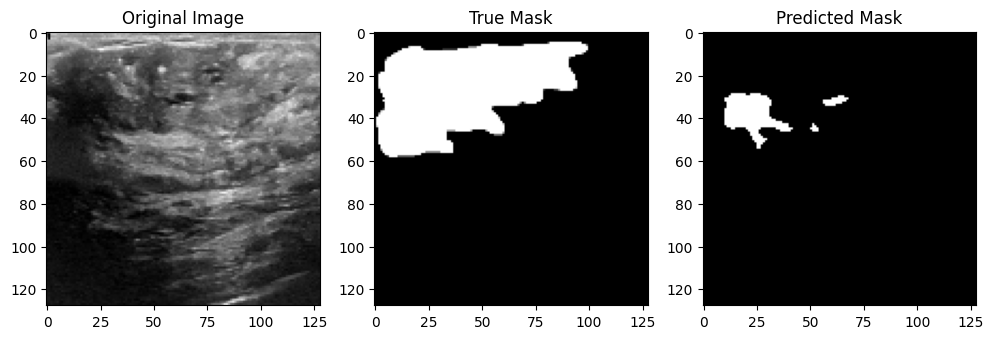

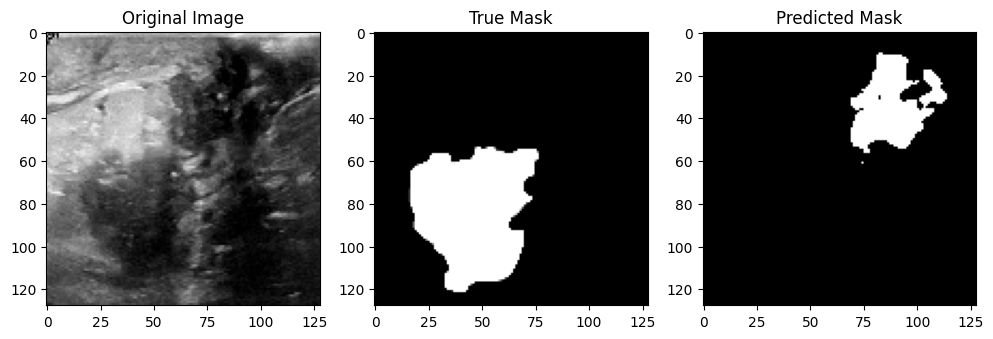

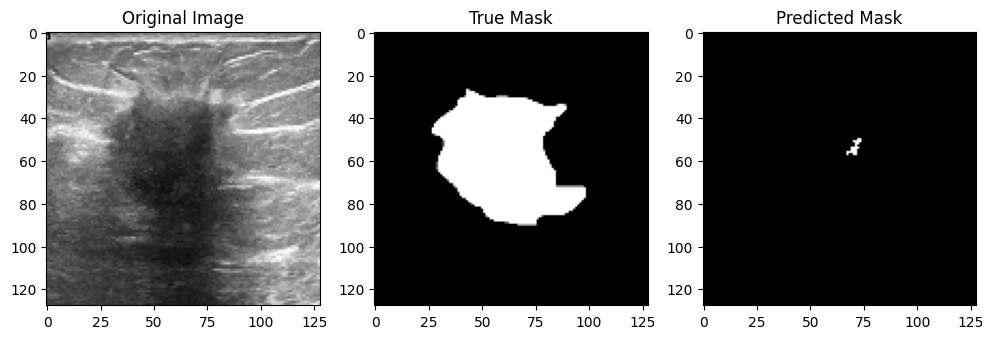

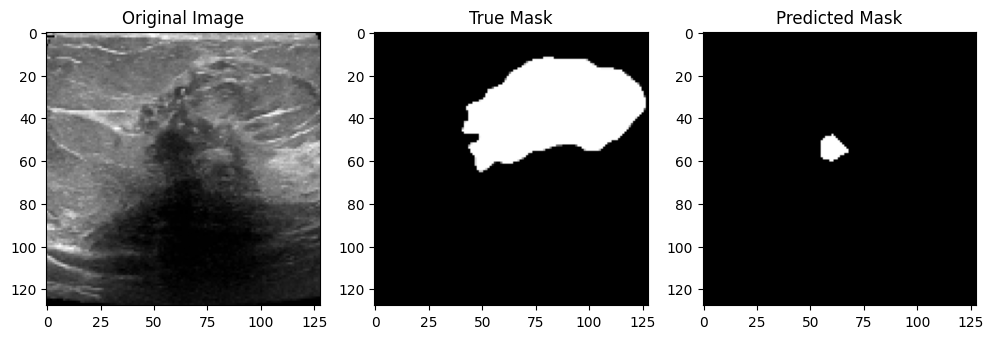

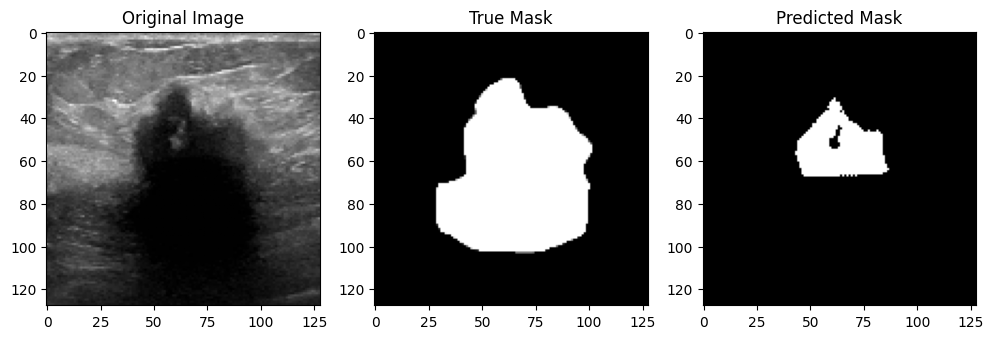

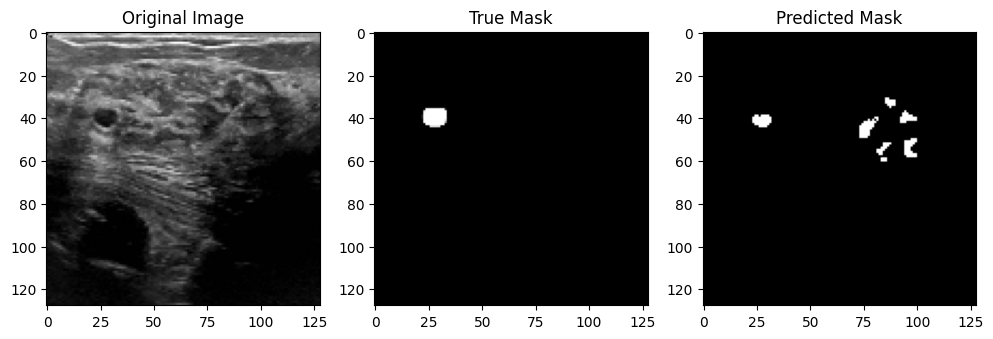

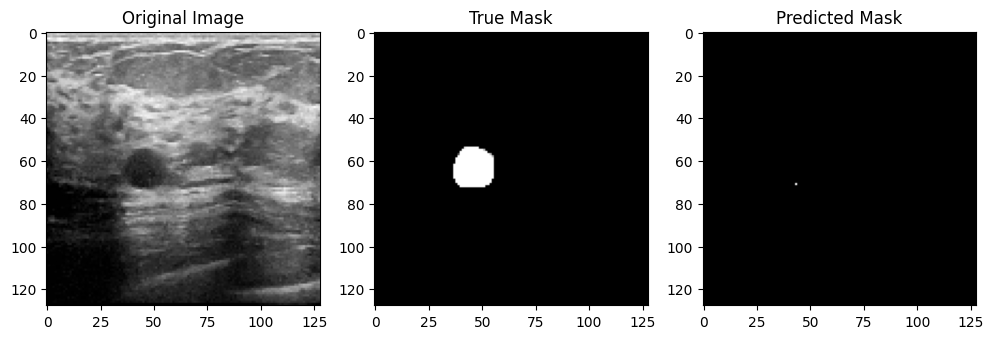

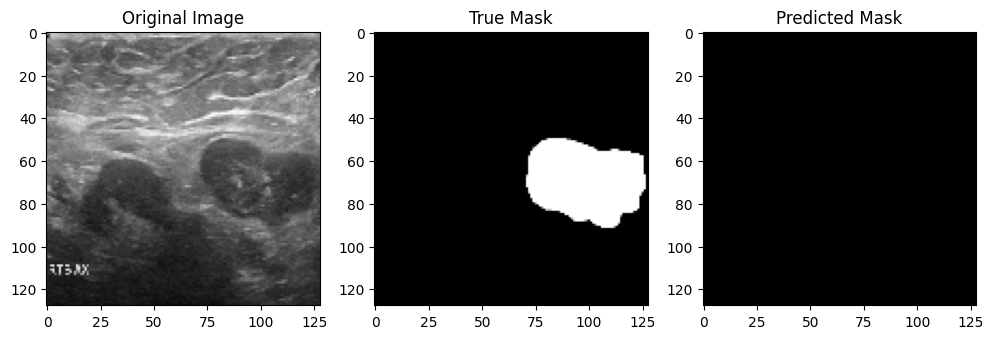

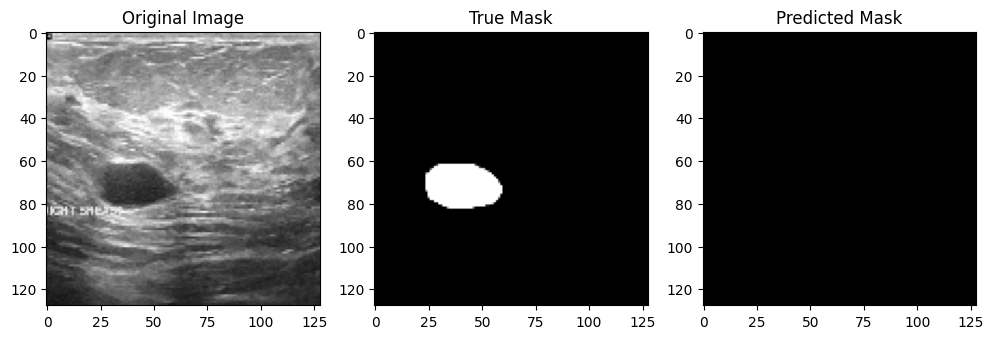

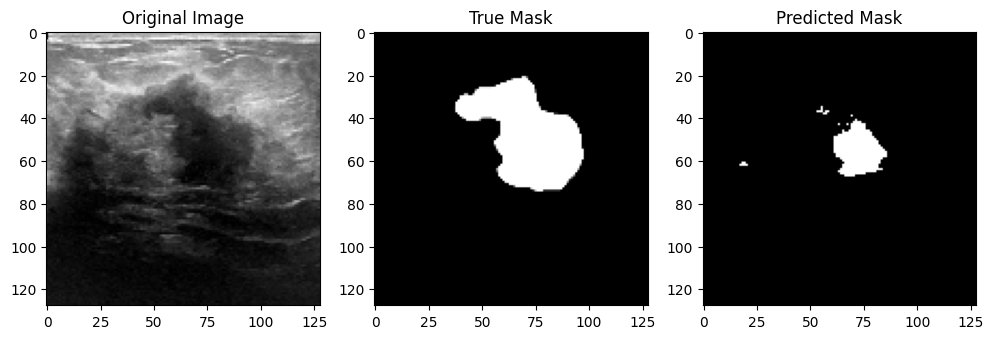

In [ ]:
n = 10
for i in range(n):
    plt.figure(figsize=(12,4))                     # Postavljamo veličinu prikaza
    plt.subplot(1,3,1)
    plt.imshow(X_test[i], cmap='gray')             # Prikaz originalne slike
    plt.title('Original Image')

    plt.subplot(1,3,2)
    plt.imshow(Y_test[i], cmap='gray')             # Prikaz prave (ground truth) maske
    plt.title('True Mask')

    plt.subplot(1,3,3)
    plt.imshow(preds[i] > 0.5, cmap='gray')         # Prikaz prediktovane maske (binarizovana sa pragom 0.5)
    plt.title('Predicted Mask')
    plt.show()

Iz priloženog se ne može reći da su predikcije "pohvalno" odradile posao. Razlog tome je sama accuracy metrika (detaljnije objašnjeno u glavnoj verziji dokumenta) zbog čega sam se prebacio na kombinaciju dice_coefficient + accuracy metrike. 